In [1]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

In [2]:
# TeX Support for plots
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

In [3]:
#-------------------------------------------------------------------------------
#               Function: Beta-binomial distribution
#-------------------------------------------------------------------------------

def betabinomial(n, a, b):

    k = np.linspace(0, n, n + 1)
    probs = sp.binom(n, k)*sp.beta(k + a, n - k + b) / sp.beta(a, b)

    return probs

In [4]:
#-------------------------------------------------------------------------------
#               Function: Main iterative loop
#-------------------------------------------------------------------------------

def vfi_mccall_basic(wages, probs, v_guess, betta, c, maxiter=10000, tol=10e-6):

    v_new = np.zeros(len(wages))

    # Value Function Iteration
    for iter1 in range(maxiter):

        # Calculate the new V given your guess and the wage distribution
        v_new = np.maximum(wages/ (1.0 - betta),c + betta * np.sum(v_guess * probs))
        # Calculate the distance between successive iterations
        # The distance here is the maximum element of the absolute difference between successive iterates
        distance = np.amax(np.abs(v_new - v_guess))
        # Print the distance
        #print(iter1, distance)
        # If the distance is sufficiently small, break the loop
        if distance < tol:
            break

        # Adjust the guess
        v_guess[:] = v_new

    # calculate the reservation wage
    reservation_wage = (1.0 - betta) * (c + betta * np.sum(v_new * probs))

    return reservation_wage, v_new

In [5]:
#-------------------------------------------------------------------------------
#               Solution of the basic McCall model
#-------------------------------------------------------------------------------

# Generate a wage distribution with
# 60 different wages ranging from 10.0 to 20.0
n = 60
w_min = 10.0
w_max = 20.0

# Beta-binomial distribution parameters
a = 600.0
b = 400.0

# Generate the distribution
wages = np.linspace(w_min,w_max,n)
probs = betabinomial(n-1,a,b)

# Parameters
betta = 0.95
c = 6.0

# calculate reservation wage and the value function\n",
result = vfi_mccall_basic(wages, probs, np.zeros(n), betta, c)

print("reservation wage =", result[0])

reservation wage = 15.605684372038406


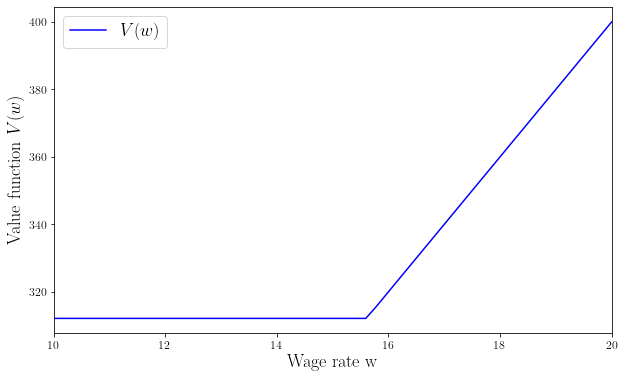

In [6]:
# Plot the value function for given wages

# Set up a figure
fig,ax=plt.subplots(figsize=(10,6))

ax.plot(wages, result[1], color='blue', label='$V(w)$')
plt.xlim((10,20))

plt.rc('axes', titlesize=18)
plt.rc('axes', labelsize=18)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.legend(loc='upper left',fontsize=18)
ax.set_xlabel('Wage rate w', fontsize=18)
ax.set_ylabel('Value function $V(w)$', fontsize=18)

plt.show()

# In case you want to save your figure (as pdf)
#fig.savefig("McCall_Value.pdf", bbox_inches='tight')

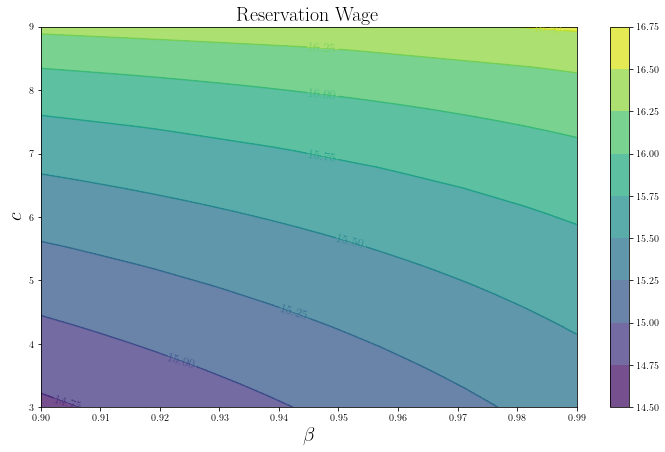

In [7]:
# Example: Contour plot

bettavec = np.linspace(0.9,0.99,20)
compvec = np.linspace(3.0,9.0,20)

res_wage_betta_c = np.empty((20,20))

for i1 in range(20):
    for i2 in range(20):
        res_wage_betta_c[i1,i2] = vfi_mccall_basic(wages, probs, np.zeros(n), bettavec[i1], compvec[i2])[0]


fig, ax=plt.subplots(figsize=(12,7))

cs1=ax.contourf(bettavec,compvec, res_wage_betta_c, alpha=0.75)
ctr1=ax.contour(bettavec,compvec, res_wage_betta_c, alpha=0.75)

plt.clabel(ctr1, inline=1, fontsize=13)
plt.colorbar(cs1, ax=ax)
ax.set_title("Reservation Wage", fontsize=20)
ax.set_xlabel("$\\beta$", fontsize=20)
ax.set_ylabel("$c$", fontsize=20)
ax.ticklabel_format(useOffset=False)

plt.show()